$$
\underbrace{\theta^*}_{\text{结果}} = \operatorname*{argmax}_{\theta} \underbrace{\sum_{(x_w, x_l) \in D} \log \underbrace{\sigma(\underbrace{f_\theta(x_w) - f_\theta(x_l)}_{\text{Deep Learning}})}_{\text{Reward Model Logic}}}_{\text{MLE (Maximum Likelihood Estimation)}}
$$

- 最顶层（指导层）：MLE，中间层（逻辑层）：概率统计建模 (Bradley-Terry)，最底层（工具层）：Deep Learning
    - 深度学习：参数化 $r_\theta$，
        - 任务：提供强大的表征能力。作用：它是一个黑盒函数 $r_\theta$，负责把文本变成数字。
    - 概率统计建模：Bradley-Terry 模型，
        - 任务：提供物理意义。
        - 作用：它定义了“数字”代表什么。它告诉我们，两个数字的差值代表了偏好的概率（$\frac{1}{1+\exp(-\Delta r)}$）。没有它，DL 输出的数字就没有可解释的意义。
    - MLE（极大似然估计）：推导 Loss Function 
- 概率统计建模（Probabilistic Modeling，定义loss），Deep Learning 为实现（universal approximator），
    - 理解 loss（mle 来定义）：通过 gradient 的计算进一步求解，理解 （Deep learning）learning dynamics
        - loss 是高度，gradient 是坡度
    - 通过 loss 通过 gradient 理解 Intransitive Preferences（非传递性偏好，$A>B>C>A$） 时的处理，以及理解所谓的 mle (一种 soft majority voting)
        - 石头 > 剪刀 > 布 > 石头
        - 长文本 > 短文本，短文本 > 幽默文本，幽默文本 > 长文本

### reward model insights

> 在 LLM 的 RLHF（Reinforcement Learning from Human Feedback）训练流程中，Reward Model (RM) 的训练本质上就是对 Bradley-Terry 模型的参数估计过程。换句话说，Reward Model 就是 一个用神经网络去拟合的 Bradley-Terry 模型。再或者说，它是 Bradley-Terry 模型的具体实现（Implementation）或参数化载体（Parameterized Instance）。

$$
\text{loss}(\theta) = -\frac{1}{\binom{K}{2}} E_{(x, y_w, y_l) \sim D} \left[ \log \left( \sigma \left( r_\theta(x, y_w) - r_\theta(x, y_l) \right) \right) \right]
$$
- reward model
- 通过最大似然估计（MLE），去拟合一个符合 Bradley-Terry 假设的概率模型。（BT 是概率统计模型）
    - 如果选手 A 的实力（或者说“**隐藏**分数”）是 $r_A$，选手 B 的实力是 $r_B$，那么 A 击败 B 的概率 $P(A \succ B)$ 定义为：
$$
P(A \succ B) = \frac{e^{r_A}}{e^{r_A} + e^{r_B}}= \sigma(r_A - r_B)
$$
- 映射到奖励模型
$$P(y_w \succ y_l \mid x) = \sigma(r_\theta(x, y_w) - r_\theta(x, y_l))$$
- 从概率到损失函数 (Loss Derivation)，为了训练这个神经网络（即找到最佳参数 $\theta$），我们需要最大化模型预测符合人类选择的概率。这就是统计学中的 最大似然估计 (MLE)。
    - $\text{Maximize } \prod_{(x, y_w, y_l) \in \mathcal{D}} P(y_w \succ y_l \mid x)$
    - $\text{Maximize } \sum \log P(y_w \succ y_l \mid x)= \sum \log \sigma(r_\theta(x, y_w) - r_\theta(x, y_l))$
    - $\text{Loss} = - \sum \log \sigma(r_\theta(x, y_w) - r_\theta(x, y_l))$

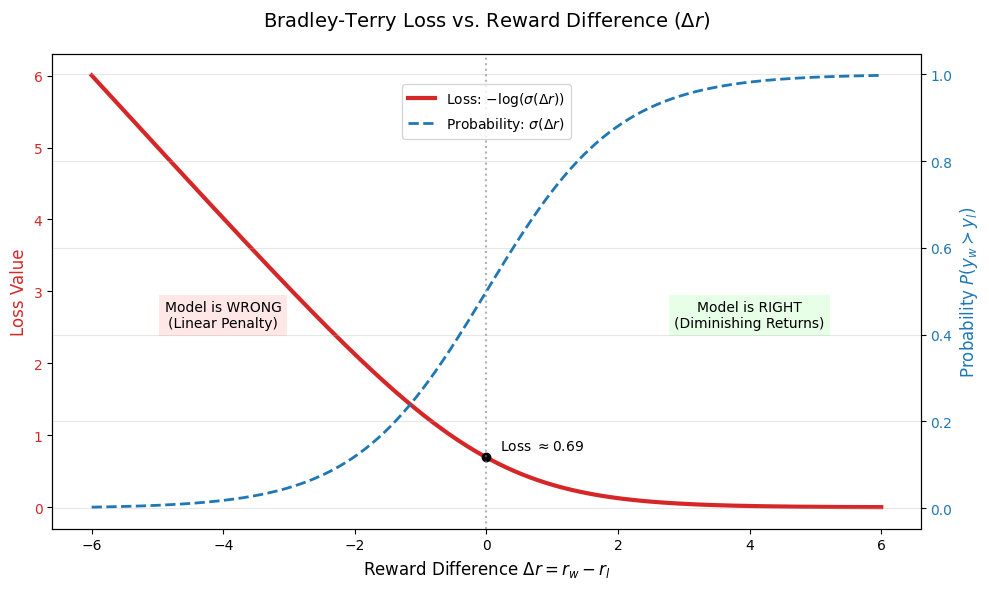

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 定义数据范围：奖励分差 delta = r_w - r_l
# 范围从 -6 (输得很惨) 到 6 (赢得轻松)
delta_r = np.linspace(-6, 6, 500)

# 2. 计算 Sigmoid 概率 P(w > l)
# 这是模型认为 "胜者回复" 确实比 "败者回复" 好的概率
prob_win = 1 / (1 + np.exp(-delta_r))

# 3. 计算 Loss (Negative Log Likelihood)
# Loss = -log(P(w > l)) = -log(sigmoid(delta_r))
loss = -np.log(prob_win)

# --- 绘图设置 ---
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'sans-serif' # 防止中文乱码兼容性问题，这里主要用英文标签

# 设置双坐标轴
ax1 = plt.gca()
ax2 = ax1.twinx()

# 绘制 Loss 曲线 (左轴)
line1, = ax1.plot(delta_r, loss, color='#D62728', linewidth=3, label=r'Loss: $-\log(\sigma(\Delta r))$')
ax1.set_xlabel(r'Reward Difference $\Delta r = r_w - r_l$', fontsize=12)
ax1.set_ylabel('Loss Value', color='#D62728', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#D62728')

# 绘制 Probability 曲线 (右轴)
line2, = ax2.plot(delta_r, prob_win, color='#1F77B4', linestyle='--', linewidth=2, label=r'Probability: $\sigma(\Delta r)$')
ax2.set_ylabel(r'Probability $P(y_w \succ y_l)$', color='#1F77B4', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#1F77B4')

# 添加辅助线和标注
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.6) # 决策边界

# 标注关键区域
ax1.text(-4, 2.5, 'Model is WRONG\n(Linear Penalty)', color='black', ha='center',
         bbox=dict(facecolor='#ffdddd', edgecolor='none', alpha=0.7))
ax1.text(4, 2.5, 'Model is RIGHT\n(Diminishing Returns)', color='black', ha='center',
         bbox=dict(facecolor='#ddffdd', edgecolor='none', alpha=0.7))

# 标注 Loss 在 0 点的值
loss_at_0 = -np.log(0.5) # approx 0.693
ax1.plot(0, loss_at_0, 'ko') 
ax1.text(0.2, loss_at_0 + 0.1, r'Loss $\approx 0.69$', fontsize=10)

# 标题和图例
plt.title(r'Bradley-Terry Loss vs. Reward Difference ($\Delta r$)', fontsize=14, pad=20)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
plt.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- $\Delta r=r_w-r_\ell, $
    - $\Delta r \ll 0, -\log(\sigma(\Delta r))=\log(1 + e^{-\Delta r}) \approx -\Delta r$，线性惩罚 (Linear Penalty)
    - $\Delta r = 0$，Loss 约为 $0.693$ ($\ln 2$)。
    - $\Delta r>0$，收益递减 (Diminishing Returns)。Loss 迅速下降并趋近于 0。但是注意，曲线变得越来越平缓（梯度消失）。
        -  一旦 $r_w$ 已经比 $r_l$ 高出一定程度（比如高出 4-5 分），Sigmoid 概率已经接近 0.99 了。此时再继续拉大分差，对降低 Loss 的贡献微乎其微。
- 最终训出的  Reward Model 不需要无限大的分差。只要能把好坏区分开（分差足够大以至于 Sigmoid 饱和），模型就会停止在该样本上的激进更新，转向去学习那些还分不清楚的样本（Hard Negatives）。（gradient 即 learning signal）
    $$
    \frac{\partial L}{\partial \theta} = \underbrace{(\sigma(\Delta r) - 1)}_{\text{权重项 } \alpha} \cdot \underbrace{\left( \nabla_\theta r(x, y_w) - \nabla_\theta r(x, y_l) \right)}_{\text{方向项}}
    $$
    - 对于错题（分错的）： 狠狠地改（梯度大）。
        - $\Delta r = -2,g \approx 0.12 - 1 = -0.88$
    - 对于难题（分不开的）： 努力地改（梯度中等） -0.5。
    - 对于送分题（已经分得更开了）： 基本不改（梯度趋近 0）。
        - $\Delta r = +6, g\approx 0.9975 - 1 = -0.0025$

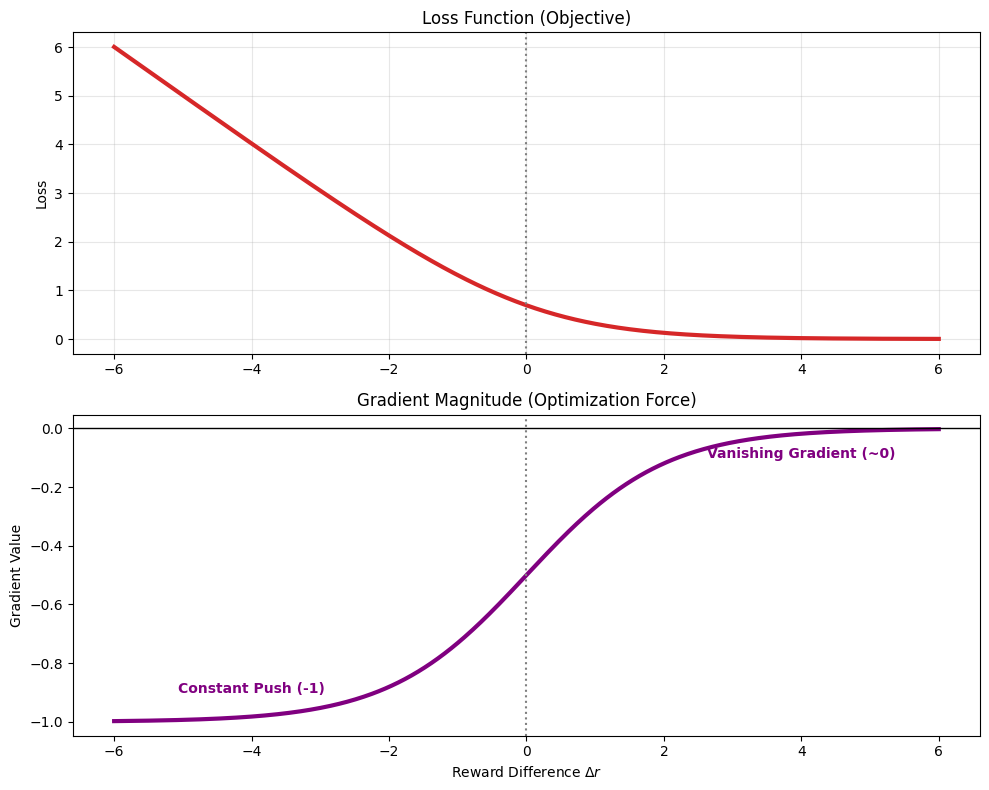

In [3]:
import numpy as np
import matplotlib.pyplot as plt

delta_r = np.linspace(-6, 6, 500)
prob_win = 1 / (1 + np.exp(-delta_r))
loss = -np.log(prob_win)

# === 新增：梯度的计算 ===
# dL/d(delta_r) = prob_win - 1
gradient = prob_win - 1 

plt.figure(figsize=(10, 8))

# 子图1：Loss (你原来的图)
plt.subplot(2, 1, 1)
plt.plot(delta_r, loss, color='#D62728', linewidth=3, label='Loss')
plt.title('Loss Function (Objective)', fontsize=12)
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.axvline(x=0, color='gray', linestyle=':')

# 子图2：Gradient (优化动力)
plt.subplot(2, 1, 2)
plt.plot(delta_r, gradient, color='purple', linewidth=3, label=r'Gradient (dL/d$\Delta r$)')
plt.title('Gradient Magnitude (Optimization Force)', fontsize=12)
plt.xlabel(r'Reward Difference $\Delta r$')
plt.ylabel('Gradient Value')
plt.axhline(y=0, color='black', linewidth=1)
plt.axvline(x=0, color='gray', linestyle=':')

# 标注梯度特性
plt.text(-4, -0.9, 'Constant Push (-1)', ha='center', color='purple', fontweight='bold')
plt.text(4, -0.1, 'Vanishing Gradient (~0)', ha='center', color='purple', fontweight='bold')

plt.tight_layout()
plt.show()

#### Intransitive Preferences

当数据中出现 $A > B > C > A$ 这种死循环时，Bradley-Terry 模型无法在这个维度上“理解”这种循环，它只能通过**把所有人的分数拉近（Flattening）**来强行达成一种妥协。
$$
\mathcal{L} = \underbrace{-\log \sigma(s_A - s_B)}_{\text{希望 } s_A > s_B} + \underbrace{-\log \sigma(s_B - s_C)}_{\text{希望 } s_B > s_C} + \underbrace{-\log \sigma(s_C - s_A)}_{\text{希望 } s_C > s_A}
$$
- 策略一：强行分出胜负（模拟线性排名）：假设模型试图通过拉大分差来“确信”其中两个关系，比如设 $s_A = 10, s_B = 0, s_C = -10$。
    - $P(A>B) \approx 1.0$ (Loss $\approx 0$) $\rightarrow$ 模型很开心。
    - $P(B>C) \approx 1.0$ (Loss $\approx 0$) $\rightarrow$ 模型很开心。
    - 但是！ $P(C>A) \approx 0.000000002$ (Loss $\approx 20$) $\rightarrow$ 模型爆炸了。
    - 在 Log Loss（对数损失）中，“非常确信地预测错了一个样本”（Confident Wrong）带来的惩罚是无穷大的。为了满足前两个关系而把第三个关系的概率压到接近 0，会导致总 Loss 极其巨大。
- 策略二：承认无知（平滑/拉平）
    - 模型决定放弃抵抗，把三个人的分数设为相等：$s_A = s_B = s_C = 0$。
    - 此时，任意两人对战的胜率预测都是 $\sigma(0) = 0.5$（50%）。
        - $P(A>B) = 0.5$ (Loss $= 0.69$)
        - $P(B>C) = 0.5$ (Loss $= 0.69$)
        - $P(C>A) = 0.5$ (Loss $= 0.69$)
    - 总 Loss $\approx 2.07$。
- 语言模型中常见的：长文本 > 短文本，短文本 > 幽默文本，幽默文本 > 长文本
    - 标准 RM 的缺陷：如果你的偏好数据里包含大量这种循环，基于 Bradley-Terry 的 RM 会“磨平”这些差异，导致模型认为这些风格都一样好，从而失去对特定风格的精细捕捉。

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 定义数据：A>B, B>C, C>A
# 使用索引: 0=A, 1=B, 2=C
# 每一行是 (winner_idx, loser_idx)
pairs = torch.tensor([
    [0, 1], # A > B
    [1, 2], # B > C
    [2, 0]  # C > A
])

# 2. 初始化 Reward Model
# 我们只需要学习3个标量：R_A, R_B, R_C
# 初始化为 0.0
# rewards = nn.Parameter(torch.zeros(3))
# rewards = nn.Parameter(torch.ones(3))
rewards = nn.Parameter(torch.tensor([1., 2., 3.]))


# 3. 定义优化器
optimizer = optim.SGD([rewards], lr=0.1)

print(f"初始分数: A={rewards[0]:.4f}, B={rewards[1]:.4f}, C={rewards[2]:.4f}")

# 4. 训练循环 (Gradient Descent)
for epoch in range(500):
    optimizer.zero_grad()
    
    # 提取 winner 和 loser 的分数
    r_winners = rewards[pairs[:, 0]]
    r_losers =  rewards[pairs[:, 1]]
    
    # 计算 Bradley-Terry Loss (Log Sigmoid Loss)
    # Loss = -log(sigmoid(r_win - r_lose))
    diff = r_winners - r_losers
    loss = -torch.log(torch.sigmoid(diff)).mean()
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss={loss.item():.4f} | Rewards: {rewards.data}")

print("\n--- 最终结果 ---")
print(f"最终分数: A={rewards[0]:.4f}, B={rewards[1]:.4f}, C={rewards[2]:.4f}")
probs = torch.sigmoid(rewards[0] - rewards[1])
print(f"模型预测 A > B 的概率: {probs:.4f}")

初始分数: A=1.0000, B=2.0000, C=3.0000
Epoch 0: Loss=0.9178 | Rewards: tensor([1.0204, 2.0000, 2.9796])
Epoch 50: Loss=0.7176 | Rewards: tensor([1.6929, 2.0000, 2.3071])
Epoch 100: Loss=0.6952 | Rewards: tensor([1.9124, 2.0000, 2.0876])
Epoch 150: Loss=0.6933 | Rewards: tensor([1.9753, 2.0000, 2.0247])
Epoch 200: Loss=0.6932 | Rewards: tensor([1.9930, 2.0000, 2.0070])
Epoch 250: Loss=0.6931 | Rewards: tensor([1.9980, 2.0000, 2.0020])
Epoch 300: Loss=0.6931 | Rewards: tensor([1.9994, 2.0000, 2.0006])
Epoch 350: Loss=0.6931 | Rewards: tensor([1.9998, 2.0000, 2.0002])
Epoch 400: Loss=0.6931 | Rewards: tensor([2.0000, 2.0000, 2.0000])
Epoch 450: Loss=0.6931 | Rewards: tensor([2.0000, 2.0000, 2.0000])

--- 最终结果 ---
最终分数: A=2.0000, B=2.0000, C=2.0000
模型预测 A > B 的概率: 0.5000


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

# 1. 定义数据：A>B, B>C, C>A
data_AB = torch.tensor([[0, 1]]).repeat(100, 1)

# 构造 50 个 B > C (1, 2)
data_BC = torch.tensor([[1, 2]]).repeat(50, 1)

# 构造 20 个 C > A (2, 0)
data_CA = torch.tensor([[2, 0]]).repeat(20, 1)

# 合并成一个大的 Batch (总样本数 N = 170)
pairs = torch.cat([data_AB, data_BC, data_CA], dim=0)

# 2. 初始化 Reward Model
# 我们只需要学习3个标量：R_A, R_B, R_C
# 初始化为 0.0
# rewards = nn.Parameter(torch.zeros(3))
# rewards = nn.Parameter(torch.ones(3))
rewards = nn.Parameter(torch.tensor([1., 2., 3.]))


# 3. 定义优化器
optimizer = optim.SGD([rewards], lr=0.1)

print(f"初始分数: A={rewards[0]:.4f}, B={rewards[1]:.4f}, C={rewards[2]:.4f}")

# 4. 训练循环 (Gradient Descent)
for epoch in range(500):
    optimizer.zero_grad()
    
    # 提取 winner 和 loser 的分数
    r_winners = rewards[pairs[:, 0]]
    r_losers =  rewards[pairs[:, 1]]
    
    # 计算 Bradley-Terry Loss (Log Sigmoid Loss)
    # Loss = -log(sigmoid(r_win - r_lose))
    diff = r_winners - r_losers
    loss = -torch.log(torch.sigmoid(diff)).mean()
    
    loss.backward()
    optimizer.step()
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}: Loss={loss.item():.4f} | Rewards: {rewards.data}")

print("\n--- 最终结果 ---")
print(f"最终分数: A={rewards[0]:.4f}, B={rewards[1]:.4f}, C={rewards[2]:.4f}")
probs = torch.sigmoid(rewards[0] - rewards[1])
print(f"模型预测 A > B 的概率: {probs:.4f}")

/home/zhangchunhui/miniconda3/envs/verl/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


初始分数: A=1.0000, B=2.0000, C=3.0000
Epoch 0: Loss=1.1737 | Rewards: tensor([1.0416, 1.9785, 2.9799])
Epoch 50: Loss=0.6300 | Rewards: tensor([2.2739, 1.5789, 2.1473])
Epoch 100: Loss=0.5408 | Rewards: tensor([2.7194, 1.5994, 1.6812])
Epoch 150: Loss=0.5181 | Rewards: tensor([2.9315, 1.6358, 1.4327])
Epoch 200: Loss=0.5113 | Rewards: tensor([3.0470, 1.6580, 1.2950])
Epoch 250: Loss=0.5090 | Rewards: tensor([3.1137, 1.6704, 1.2159])
Epoch 300: Loss=0.5082 | Rewards: tensor([3.1532, 1.6774, 1.1694])
Epoch 350: Loss=0.5079 | Rewards: tensor([3.1770, 1.6814, 1.1416])
Epoch 400: Loss=0.5078 | Rewards: tensor([3.1914, 1.6838, 1.1248])
Epoch 450: Loss=0.5078 | Rewards: tensor([3.2002, 1.6852, 1.1146])

--- 最终结果 ---
最终分数: A=3.2055, B=1.6860, C=1.1085
模型预测 A > B 的概率: 0.8205
